In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\Unsupervised-ML\03_Hierarchical_Clustering\data\Global GDP Explorer 2025 (World Bank  UN Data).csv")

In [85]:
df.head()

,Unnamed: 0,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,0,United States,"$27,720,700,000,000",27.721 trillion,2.89%,343477335,"$80,706",26.11%
1,1,China,"$17,794,800,000,000",17.795 trillion,5.25%,1422584933,"$12,509",16.76%
2,2,Germany,"$4,525,700,000,000",4.526 trillion,−0.27%,84548231,"$53,528",4.26%
3,3,Japan,"$4,204,490,000,000",4.204 trillion,1.68%,124370947,"$33,806",3.96%
4,4,India,"$3,567,550,000,000",3.568 trillion,8.15%,1438069596,"$2,481",3.36%


## Basic Checks

In [86]:
df.shape

(181, 8)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           181 non-null    int64 
 1   Country              181 non-null    object
 2   GDP (nominal, 2023)  181 non-null    object
 3   GDP (abbrev.)        181 non-null    object
 4   GDP Growth           181 non-null    object
 5   Population 2023      181 non-null    int64 
 6   GDP per capita       181 non-null    object
 7   Share of World GDP   181 non-null    object
dtypes: int64(2), object(6)
memory usage: 11.4+ KB


In [88]:
df.isnull().sum()

Unnamed: 0             0
Country                0
GDP (nominal, 2023)    0
GDP (abbrev.)          0
GDP Growth             0
Population 2023        0
GDP per capita         0
Share of World GDP     0
dtype: int64

In [89]:
df=df.drop(['Unnamed: 0'], axis=1)

In [90]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,"$27,720,700,000,000",27.721 trillion,2.89%,343477335,"$80,706",26.11%
1,China,"$17,794,800,000,000",17.795 trillion,5.25%,1422584933,"$12,509",16.76%
2,Germany,"$4,525,700,000,000",4.526 trillion,−0.27%,84548231,"$53,528",4.26%
3,Japan,"$4,204,490,000,000",4.204 trillion,1.68%,124370947,"$33,806",3.96%
4,India,"$3,567,550,000,000",3.568 trillion,8.15%,1438069596,"$2,481",3.36%


In [91]:
df['Country'].unique()

array(['United States', 'China', 'Germany', 'Japan', 'India',
       'United Kingdom', 'France', 'Italy', 'Brazil', 'Canada', 'Russia',
       'Mexico', 'Australia', 'South Korea', 'Spain', 'Indonesia',
       'Netherlands', 'Turkey', 'Saudi Arabia', 'Switzerland', 'Poland',
       'Argentina', 'Belgium', 'Sweden', 'Ireland', 'Thailand',
       'United Arab Emirates', 'Israel', 'Austria', 'Singapore', 'Norway',
       'Bangladesh', 'Philippines', 'Vietnam', 'Denmark', 'Iran',
       'Malaysia', 'Egypt', 'Hong Kong', 'South Africa', 'Nigeria',
       'Colombia', 'Romania', 'Czech Republic (Czechia)', 'Pakistan',
       'Chile', 'Finland', 'Portugal', 'Peru', 'Kazakhstan',
       'New Zealand', 'Iraq', 'Algeria', 'Greece', 'Qatar', 'Hungary',
       'Ukraine', 'Kuwait', 'Ethiopia', 'Morocco', 'Slovakia',
       'Dominican Republic', 'Ecuador', 'Sudan', 'Oman', 'Kenya',
       'Guatemala', 'Bulgaria', 'Uzbekistan', 'Costa Rica', 'Luxembourg',
       'Angola', 'Croatia', 'Sri Lanka', 'Pana

In [92]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,"$27,720,700,000,000",27.721 trillion,2.89%,343477335,"$80,706",26.11%
1,China,"$17,794,800,000,000",17.795 trillion,5.25%,1422584933,"$12,509",16.76%
2,Germany,"$4,525,700,000,000",4.526 trillion,−0.27%,84548231,"$53,528",4.26%
3,Japan,"$4,204,490,000,000",4.204 trillion,1.68%,124370947,"$33,806",3.96%
4,India,"$3,567,550,000,000",3.568 trillion,8.15%,1438069596,"$2,481",3.36%


In [93]:
df['GDP (nominal, 2023)'] = df['GDP (nominal, 2023)'].replace('[\$,]', '', regex=True).astype(float)

df['GDP per capita'] = df['GDP per capita'].replace('[\$,]', '', regex=True).astype(float)

In [94]:
df.head()

,Country,"GDP (nominal, 2023)",GDP (abbrev.),GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,2.772070e+13,27.721 trillion,2.89%,343477335,80706.0,26.11%
1,China,1.779480e+13,17.795 trillion,5.25%,1422584933,12509.0,16.76%
2,Germany,4.525700e+12,4.526 trillion,−0.27%,84548231,53528.0,4.26%
3,Japan,4.204490e+12,4.204 trillion,1.68%,124370947,33806.0,3.96%
4,India,3.567550e+12,3.568 trillion,8.15%,1438069596,2481.0,3.36%


In [95]:
df.drop(columns=['GDP (abbrev.)'], inplace=True)

In [96]:
df.isnull().sum()

Country                0
GDP (nominal, 2023)    0
GDP Growth             0
Population 2023        0
GDP per capita         0
Share of World GDP     0
dtype: int64

In [97]:
df.head()

,Country,"GDP (nominal, 2023)",GDP Growth,Population 2023,GDP per capita,Share of World GDP
0,United States,2.772070e+13,2.89%,343477335,80706.0,26.11%
1,China,1.779480e+13,5.25%,1422584933,12509.0,16.76%
2,Germany,4.525700e+12,−0.27%,84548231,53528.0,4.26%
3,Japan,4.204490e+12,1.68%,124370947,33806.0,3.96%
4,India,3.567550e+12,8.15%,1438069596,2481.0,3.36%


In [98]:
df[df['Population 2023']<14222]

,Country,"GDP (nominal, 2023)",GDP Growth,Population 2023,GDP per capita,Share of World GDP
180,Tuvalu,62280312.0,3.85%,9816,6345.0,0.000059%


## Univariate Analysis

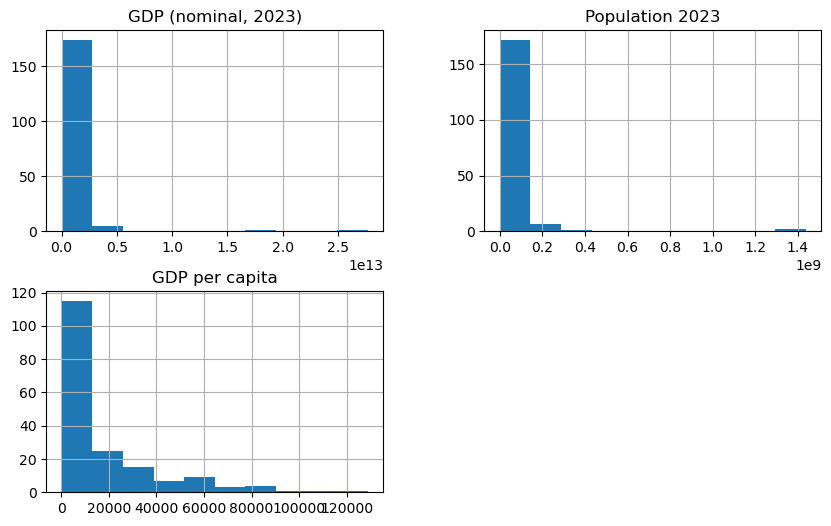

In [99]:
df.hist(figsize=(10, 6))
plt.show()

## Conclusion
### it’s heavily skewed with extreme outliers,
### 1) Every country have low GDP (nominal, 2023).
### 2) Every country have lower GDP per capita, with some have higher GDP per capita.
### 3) Population is highest in india and lowest in Tuvalu 

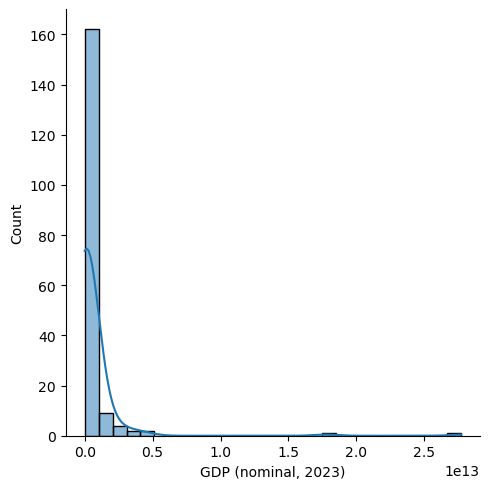

In [100]:
sns.displot(data=df, x='GDP (nominal, 2023)', kde=True)

### Let us apply transformation

In [101]:
df['GDP_log'] = np.log1p(df['GDP (nominal, 2023)'])
df['Population_log'] = np.log1p(df['Population 2023'])
df['GDP_per_capita_log'] = np.log1p(df['GDP per capita'])

In [102]:
df.head()

,Country,"GDP (nominal, 2023)",GDP Growth,Population 2023,GDP per capita,Share of World GDP,GDP_log,Population_log,GDP_per_capita_log
0,United States,2.772070e+13,2.89%,343477335,80706.0,26.11%,30.953201,19.654632,11.298581
1,China,1.779480e+13,5.25%,1422584933,12509.0,16.76%,30.509927,21.075741,9.434284
2,Germany,4.525700e+12,−0.27%,84548231,53528.0,4.26%,29.140793,18.252833,10.887979
3,Japan,4.204490e+12,1.68%,124370947,33806.0,3.96%,29.067174,18.638779,10.428423
4,India,3.567550e+12,8.15%,1438069596,2481.0,3.36%,28.902900,21.086567,7.816820


In [111]:
df['GDP Growth'] = (
    df['GDP Growth']
    .str.replace('%', '', regex=False)   # remove %
    .str.replace('−', '-', regex=False)  # fix unicode minus (very important)
    .str.strip()                         # remove spaces
)

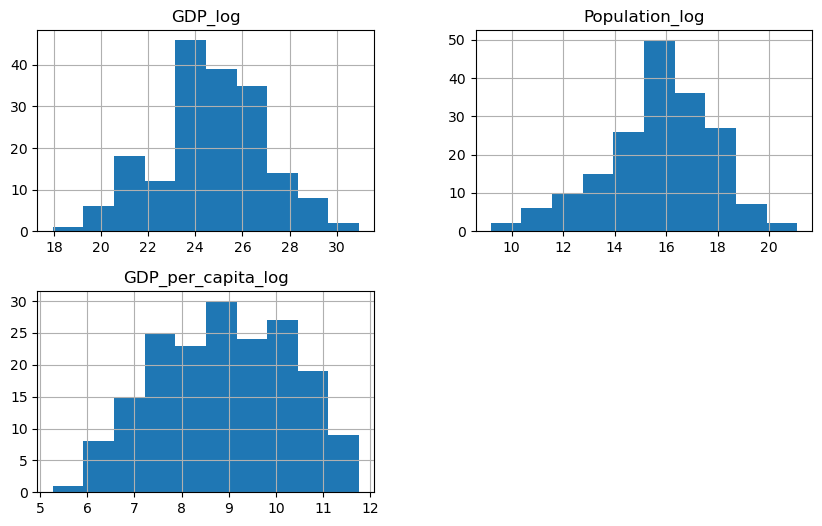

In [103]:
df[['GDP_log', 'Population_log', 'GDP_per_capita_log']].hist(figsize=(10,6))
plt.show()

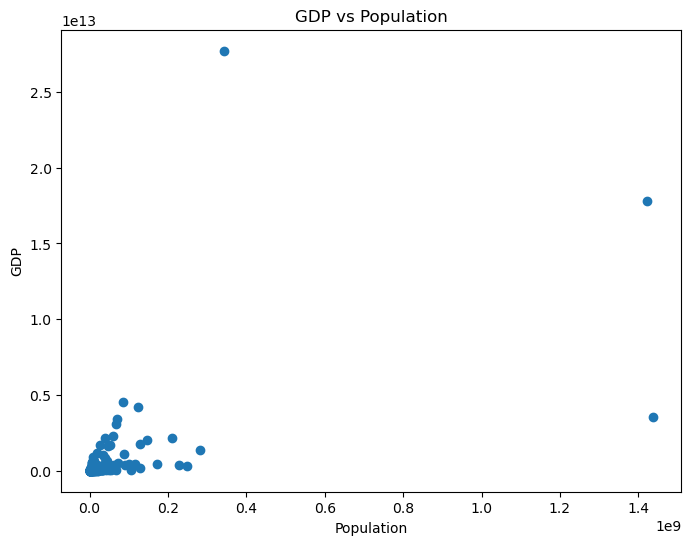

In [ ]:
# GDP vs Population without transformation 

plt.figure(figsize=(8,6))
plt.scatter(df['Population 2023'], df['GDP (nominal, 2023)'])
plt.xlabel("Population")
plt.ylabel("GDP")
plt.title("GDP vs Population")
plt.show()

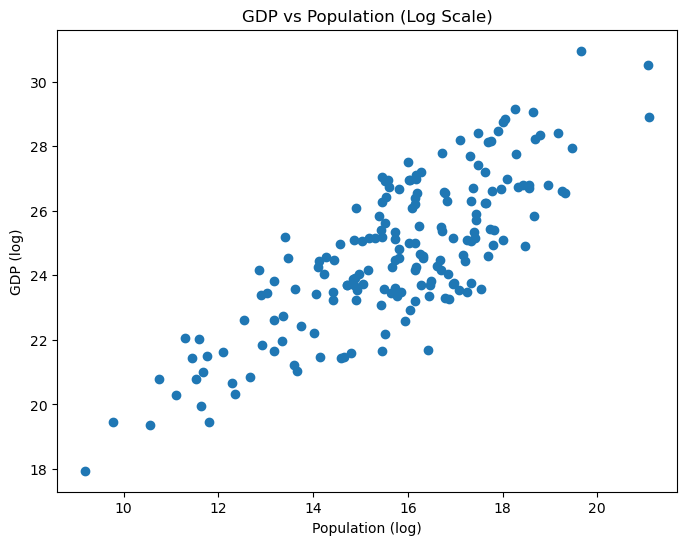

In [ ]:
# GDP vs Population with transformation 

plt.figure(figsize=(8,6))
plt.scatter(df['Population_log'], df['GDP_log'])
plt.xlabel("Population (log)")
plt.ylabel("GDP (log)")
plt.title("GDP vs Population (Log Scale)")
plt.show()

### There is a strong positive correlation between population and GDP, indicating that larger countries tend to have higher total economic output. However, the variation in GDP for similar population levels suggests that other factors such as productivity and economic development also play a significant role.

In [106]:
df[['GDP_log','Population_log']].corr()

,GDP_log,Population_log
GDP_log,1.000000,0.800338
Population_log,0.800338,1.000000


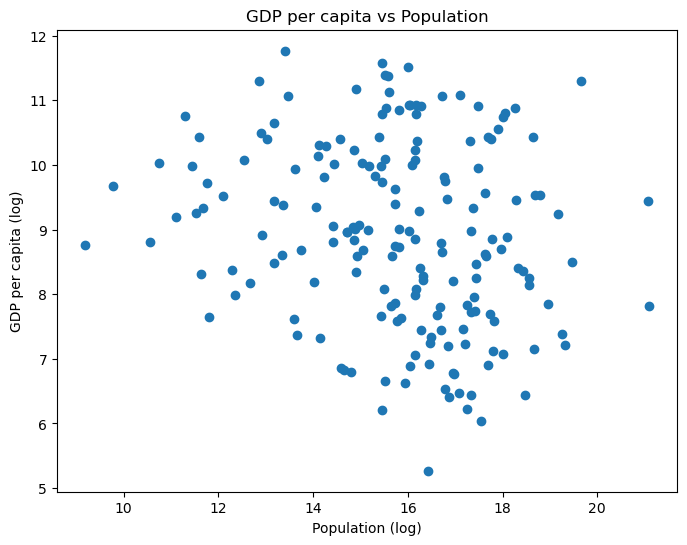

In [107]:
## GDP per capita vs Population

plt.figure(figsize=(8,6))
plt.scatter(df['Population_log'], df['GDP_per_capita_log'])
plt.xlabel("Population (log)")
plt.ylabel("GDP per capita (log)")
plt.title("GDP per capita vs Population")
plt.show()

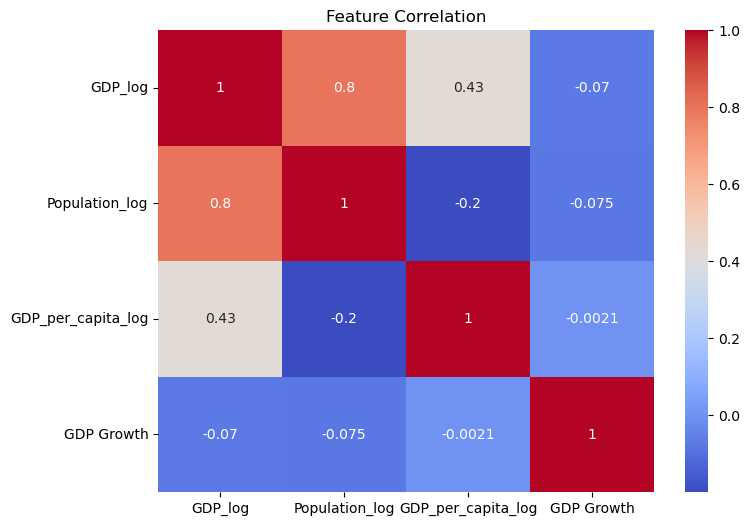

In [112]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['GDP_log','Population_log','GDP_per_capita_log','GDP Growth']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

### Correlation analysis shows a strong positive relationship between GDP and population (0.8), indicating that larger countries tend to have higher total economic output. GDP per capita shows weak correlation with population, suggesting that economic development is independent of country size. GDP growth exhibits near-zero correlation with other features, making it an independent and valuable feature for clustering